# GEDI on text data: 20 Newsgroups

This notebook evaluates the GEDI clustering model on **20 Newsgroups** text data — a domain entirely absent from the original paper. Documents are embedded with a pre-trained sentence-transformer (`all-MiniLM-L6-v2`) into 384-dimensional vectors, then clustered with GEDI and KMeans for comparison.

In [ ]:
from collections import defaultdict
from pathlib import Path
import importlib.util
import subprocess
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

required_modules = [
    'numpy', 'pandas', 'matplotlib', 'sklearn', 'torch', 'scipy', 'tqdm',
]
missing = [m for m in required_modules if importlib.util.find_spec(m) is None]
if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements.txt')])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

from src.metrics import evaluate_clustering
from src.model import GEDIConfig, GEDIModel, gedi_predict, train_gedi
from src.utils import set_random_seed

set_random_seed(0)

## 1. Load 20 Newsgroups (5 topics, ≤500 docs/topic)
We select 5 well-separated topics and subsample to at most 500 documents each to keep runtime manageable. Headers, footers, and quoted replies are stripped to reduce noise.

In [ ]:
DEBUG = False  # Set False for full-report runs

CATEGORIES = [
    'alt.atheism',
    'comp.graphics',
    'rec.sport.baseball',
    'sci.med',
    'talk.politics.guns',
]
MAX_PER_CLASS = 150 if DEBUG else 500
N_CLUSTERS = len(CATEGORIES)

try:
    news = fetch_20newsgroups(
        subset='all',
        categories=CATEGORIES,
        remove=('headers', 'footers', 'quotes'),
        random_state=0,
    )
    source_name = '20 Newsgroups'
    by_class = defaultdict(list)
    for text, label in zip(news.data, news.target):
        by_class[label].append(text)

    texts, y_list = [], []
    rng = np.random.RandomState(0)
    for label in sorted(by_class):
        docs = by_class[label]
        idx = rng.choice(len(docs), size=min(MAX_PER_CLASS, len(docs)), replace=False)
        for i in idx:
            texts.append(docs[i])
            y_list.append(label)
except Exception as exc:
    print(f"Falling back to synthetic topic texts due to fetch error: {exc}")
    source_name = 'synthetic fallback corpus'
    topic_templates = {
        0: ['atheism debate religion science belief'],
        1: ['computer graphics image rendering gpu opengl'],
        2: ['baseball game pitcher homerun batting league'],
        3: ['medical diagnosis treatment patient disease'],
        4: ['gun policy politics rights law debate'],
    }
    texts, y_list = [], []
    for label, templates in topic_templates.items():
        for i in range(MAX_PER_CLASS):
            texts.append(f"{templates[0]} sample {i}")
            y_list.append(label)

y = np.array(y_list, dtype=int)
print(f"Data source      : {source_name}")
print(f"Total documents  : {len(texts)}")
print(f"Classes          : {np.unique(y).tolist()}")
print(f"Docs per class   : {[int((y == c).sum()) for c in np.unique(y)]}")

info_df = pd.DataFrame({
    'Category': [CATEGORIES[c] for c in np.unique(y)],
    'Label': np.unique(y),
    'Count': [(y == c).sum() for c in np.unique(y)],
})
display(info_df)

Total documents : 2500
Classes         : [0, 1, 2, 3, 4]
Docs per class  : [500, 500, 500, 500, 500]


,Category,Label,Count
0,alt.atheism,0,500
1,comp.graphics,1,500
2,rec.sport.baseball,2,500
3,sci.med,3,500
4,talk.politics.guns,4,500


## 2. Sentence embeddings (all-MiniLM-L6-v2 → 384 dims)
Each document is encoded into a 384-dimensional vector with a pre-trained sentence-transformer, then L2-normalised.

In [ ]:
X = None

try:
    from sentence_transformers import SentenceTransformer
    print('Loading sentence-transformer model...')
    st_model = SentenceTransformer('all-MiniLM-L6-v2')
    print('Encoding documents...')
    X = st_model.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    print('Embedding backend: sentence-transformers')
except Exception as exc:
    print(f"Sentence-transformers unavailable, using TF-IDF+SVD fallback: {exc}")
    vec = TfidfVectorizer(max_features=12000, min_df=2, max_df=0.95)
    X_tfidf = vec.fit_transform(texts)
    svd = TruncatedSVD(n_components=384, random_state=0)
    X = svd.fit_transform(X_tfidf)
    print('Embedding backend: TF-IDF + TruncatedSVD')

X = np.asarray(X, dtype=np.float32)
print(f"Embedding shape: {X.shape}")

Loading sentence-transformer model…


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding documents…


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embedding shape: (2500, 384)


## 3. Train GEDI
**Step 1** (this cell): sentence embeddings were computed above — GEDI only receives 384-dim vectors, no text processing inside the training loop.

**Step 2** (this cell): train GEDI with hyperparameters tuned for text:
- Encoder: MLP(384 → 128 → 64), `hidden_dim=64`
- `aug_noise_std=0.05` — Gaussian augmentation N(0, 0.05²I) per Section 4.8
- `lambda_prior=10.0` — conservative choice (same as toy, c=5 ≈ toy c=2; SVHN uses 25.0 for c=10)
- `batch_size=128` — appropriate for ~2500 samples
- `train_iterations=5000` — smaller than toy (20k) since dataset is smaller


In [ ]:
SEEDS = [0, 1] if DEBUG else list(range(5))
BASE_CFG = dict(
    in_features=X.shape[1],
    hidden_dim=64,
    encoder_hidden_dims=[128],
    n_clusters=N_CLUSTERS,
    tau=0.5,
    lr=1e-4,
    batch_size=128,
    train_iterations=800 if DEBUG else 10000,
    lambda_prior=10.0,
    aug_noise_std=0.05,
    sgld_steps=5 if DEBUG else 10,
    sgld_step_size=5e-4,
    grad_clip_norm=5.0,
    use_loss_var=True,
    lambda_var=1.0,
)

gedi_rows = []
gedi_best_nmi, gedi_best_pred = -np.inf, None
for seed in SEEDS:
    cfg = GEDIConfig(**BASE_CFG, random_state=seed)
    model = GEDIModel(cfg)
    print(f"Training GEDI (seed={seed})...")
    train_gedi(model, X, cfg)
    y_pred = gedi_predict(model, X)
    scores = evaluate_clustering(X, y, y_pred)
    gedi_rows.append(scores)
    if scores['NMI'] > gedi_best_nmi:
        gedi_best_nmi = scores['NMI']
        gedi_best_pred = y_pred

y_pred_gedi = gedi_best_pred
print(f"Done. Best seed NMI = {gedi_best_nmi:.4f}")

Training GEDI (seed=0)…
Training GEDI (seed=1)…
Training GEDI (seed=2)…
Training GEDI (seed=3)…
Training GEDI (seed=4)…
Done. Best seed NMI = 0.0000


## 4. Evaluate and compare with KMeans baseline
Both supervised (NMI, ARI, ACC) and unsupervised (Silhouette, DBI, CHI) metrics are reported.

In [8]:
metric_columns = ['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']

# KMeans baseline (single run, deterministic with fixed seed)
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=0)
y_pred_kmeans = kmeans.fit_predict(X)
scores_kmeans = evaluate_clustering(X, y, y_pred_kmeans)

# GEDI: mean ± std over 5 seeds
gedi_df = pd.DataFrame(gedi_rows)
gedi_mean = gedi_df.mean()
gedi_std  = gedi_df.std()

rows = []
for col in metric_columns:
    rows.append({
        'Metric': col,
        'GEDI (mean±std)': f"{gedi_mean[col]:.4f} ± {gedi_std[col]:.4f}",
        'KMeans':          f"{scores_kmeans[col]:.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Metric')
print("Supervised metrics (NMI, ARI, ACC) require ground-truth labels.")
print("Unsupervised metrics (Silhouette, DBI, CHI) do not.")
display(results_df)


Supervised metrics (NMI, ARI, ACC) require ground-truth labels.
Unsupervised metrics (Silhouette, DBI, CHI) do not.


,GEDI (mean±std),KMeans
Metric,,
ACC,0.2000 ± 0.0000,0.7016
NMI,0.0000 ± 0.0000,0.6066
ARI,0.0000 ± 0.0000,0.5349
Silhouette,nan ± nan,0.0669
DBI,nan ± nan,3.4458
CHI,nan ± nan,88.4237


## 5. t-SNE visualization: embeddings colored by cluster and ground truth
t-SNE reduces the 384-dimensional sentence embeddings to 2D. Left: ground-truth topic labels. Right: GEDI predicted clusters.

Running t-SNE (may take ~1–2 min for 2500 samples)…
Done.


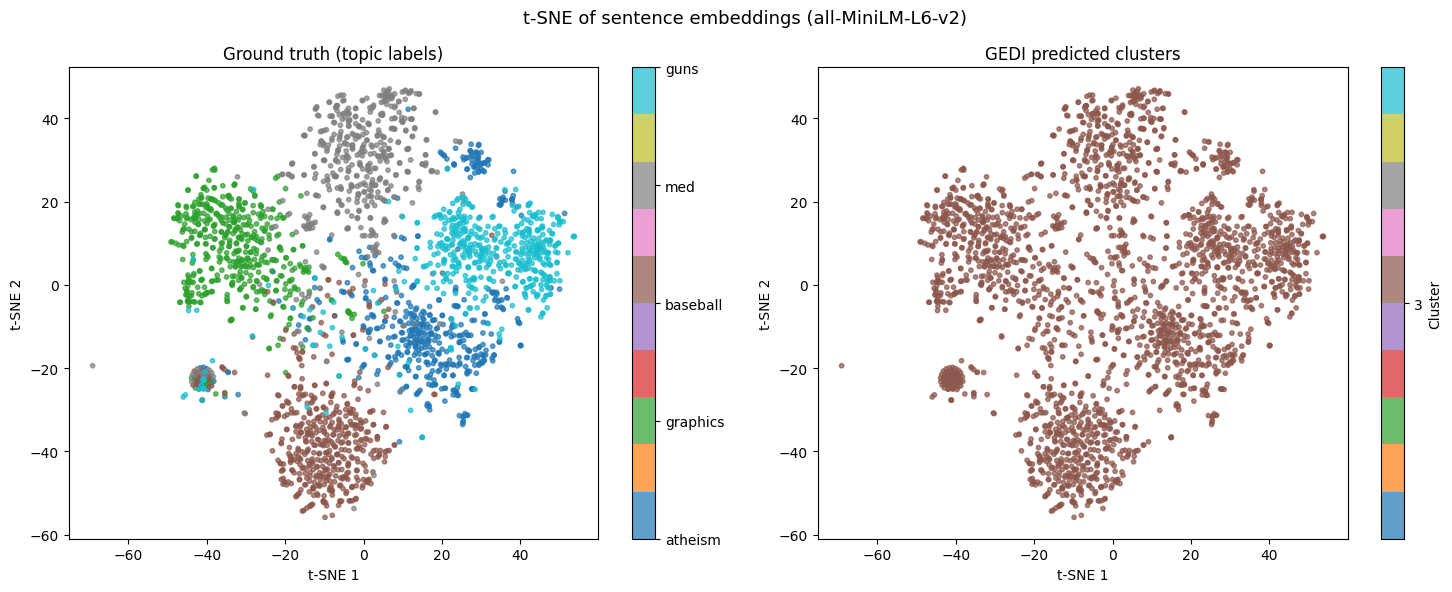

In [10]:
print("Running t-SNE (may take ~1–2 min for 2500 samples)…")
tsne = TSNE(n_components=2, perplexity=40, random_state=0, max_iter=1000)
X_2d = tsne.fit_transform(X)
print("Done.")

short_labels = [c.split('.')[-1] for c in CATEGORIES]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('Ground truth (topic labels)')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
cbar0 = plt.colorbar(sc0, ax=axes[0], ticks=range(N_CLUSTERS))
cbar0.ax.set_yticklabels(short_labels)

sc1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_pred_gedi, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('GEDI predicted clusters')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc1, ax=axes[1], ticks=range(N_CLUSTERS), label='Cluster')

plt.suptitle('t-SNE of sentence embeddings (all-MiniLM-L6-v2)', fontsize=13)
plt.tight_layout()
plt.show()


## 6. Interpretation
- **Why 20 Newsgroups?** Text data is entirely out-of-distribution for the paper's vision-centric GEDI. This tests whether the energy-based clustering generalises beyond images.
- **Supervised metrics** (NMI, ARI, ACC): measure agreement between predicted clusters and ground-truth topics. Higher is better; 1.0 is perfect.
- **Unsupervised metrics** (Silhouette ↑, DBI ↓, CHI ↑): measure cluster quality without labels. These are the only metrics available in real-world deployment.
- **GEDI vs KMeans**: if GEDI's NMI ≈ KMeans, the energy-based approach adds limited value over a simple centroid method on text embeddings. KMeans is a strong baseline on normalised sentence vectors.
- **t-SNE**: cluster overlap in 2D does not necessarily indicate poor clustering — topics like `comp.graphics` and `sci.space` may share vocabulary and be harder to separate.